<center> <h1> Netflix Data Science Project </h1> </center>

In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

#Ignore all incoming warnings (if any):
warnings.filterwarnings("ignore")

# Load dataset
df = pd.read_csv("dataset/NetFlix.csv/NetFlix.csv")

# Copy original data
df_clean = df.copy()

# Standardize column names
df_clean.columns = (
    df_clean.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

# Remove duplicates
df_clean.drop_duplicates(inplace=True)

# Replace fake null strings with actual NaN
df_clean.replace(['nan', 'None', ''], np.nan, inplace=True)

# Strip spaces from text columns
text_cols = ['show_id', 'type', 'title', 'director', 'cast', 'country', 'rating', 'genres', 'description']
for col in text_cols:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].astype(str).str.strip()
        df_clean[col] = df_clean[col].replace("nan", np.nan)

# Fill missing text values
for col in ['director', 'cast', 'country', 'rating', 'genres', 'description']:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].fillna('Unknown')

# Convert date_added to datetime
df_clean['date_added'] = pd.to_datetime(df_clean['date_added'], errors='coerce', dayfirst=True)

# Fill missing date_added with median date
median_date = df_clean['date_added'].dropna().median()
df_clean['date_added'] = df_clean['date_added'].fillna(median_date)

# Ensure release_year is numeric
df_clean['release_year'] = pd.to_numeric(df_clean['release_year'], errors='coerce')
df_clean['release_year'] = df_clean['release_year'].fillna(df_clean['release_year'].median())

# Clean duration column: extract numeric value from strings like "90 min", "2 Seasons"
df_clean['duration'] = (
    df_clean['duration']
    .astype(str)
    .str.extract(r'(\d+)')[0]
)
df_clean['duration'] = pd.to_numeric(df_clean['duration'], errors='coerce')
df_clean['duration'] = df_clean['duration'].fillna(df_clean['duration'].median())

# Clean comma-separated text columns
def clean_comma_separated_text(x):
    if pd.isna(x) or str(x).strip().lower() == 'unknown':
        return 'Unknown'
    parts = [item.strip() for item in str(x).split(',')]
    return ', '.join(parts)

for col in ['cast', 'country', 'genres']:
    df_clean[col] = df_clean[col].apply(clean_comma_separated_text)

# Feature engineering
df_clean['added_year'] = df_clean['date_added'].dt.year
df_clean['added_month'] = df_clean['date_added'].dt.month
df_clean['added_day'] = df_clean['date_added'].dt.day

df_clean['cast_count'] = df_clean['cast'].apply(lambda x: 0 if x == 'Unknown' else len([i for i in str(x).split(',') if i.strip()]))
df_clean['country_count'] = df_clean['country'].apply(lambda x: 0 if x == 'Unknown' else len([i for i in str(x).split(',') if i.strip()]))
df_clean['genre_count'] = df_clean['genres'].apply(lambda x: 0 if x == 'Unknown' else len([i for i in str(x).split(',') if i.strip()]))
df_clean['description_length'] = df_clean['description'].apply(lambda x: len(str(x).strip()))

# Final checks
print("Final shape:", df_clean.shape)
print("\nMissing values after cleaning:\n")
print(df_clean.isnull().sum())

print("\nData types:\n")
print(df_clean.dtypes)

Final shape: (7787, 19)

Missing values after cleaning:

show_id               0
type                  0
title                 0
director              0
cast                  0
country               0
date_added            0
release_year          0
rating                0
duration              0
genres                0
description           0
added_year            0
added_month           0
added_day             0
cast_count            0
country_count         0
genre_count           0
description_length    0
dtype: int64

Data types:

show_id                       object
type                          object
title                         object
director                      object
cast                          object
country                       object
date_added            datetime64[ns]
release_year                   int64
rating                        object
duration                       int64
genres                        object
description                   object
added_year      

In [70]:
df_clean.shape

(7787, 19)

In [71]:
df_clean.describe()

,date_added,release_year,duration,added_year,added_month,added_day,cast_count,country_count,genre_count,description_length
count,7787,7787.000000,7787.000000,7787.000000,7787.000000,7787.000000,7787.000000,7787.000000,7787.000000,7787.000000
mean,2019-01-02 21:19:40.274817024,2013.932580,69.122769,2018.494029,6.778991,12.372159,7.185694,1.163863,2.192243,143.100424
min,2008-01-01 00:00:00,1925.000000,1.000000,2008.000000,1.000000,1.000000,0.000000,0.000000,1.000000,61.000000
25%,2018-02-01 00:00:00,2013.000000,2.000000,2018.000000,4.000000,1.000000,4.000000,1.000000,2.000000,140.000000
50%,2019-03-08 00:00:00,2017.000000,88.000000,2019.000000,7.000000,12.000000,8.000000,1.000000,2.000000,146.000000
75%,2020-01-17 12:00:00,2018.000000,106.000000,2020.000000,10.000000,20.000000,10.000000,1.000000,3.000000,149.000000
max,2021-01-16 00:00:00,2021.000000,312.000000,2021.000000,12.000000,31.000000,50.000000,12.000000,3.000000,248.000000
std,NaN,8.757395,50.950743,1.387371,3.591858,9.951626,4.859990,0.732262,0.786086,10.614146


In [72]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7787 entries, 0 to 7786
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   show_id             7787 non-null   object        
 1   type                7787 non-null   object        
 2   title               7787 non-null   object        
 3   director            7787 non-null   object        
 4   cast                7787 non-null   object        
 5   country             7787 non-null   object        
 6   date_added          7787 non-null   datetime64[ns]
 7   release_year        7787 non-null   int64         
 8   rating              7787 non-null   object        
 9   duration            7787 non-null   int64         
 10  genres              7787 non-null   object        
 11  description         7787 non-null   object        
 12  added_year          7787 non-null   int32         
 13  added_month         7787 non-null   int32       

### Q1] Netflix wants to segment its content catalog into groups based on content characteristics such as release year and duration.

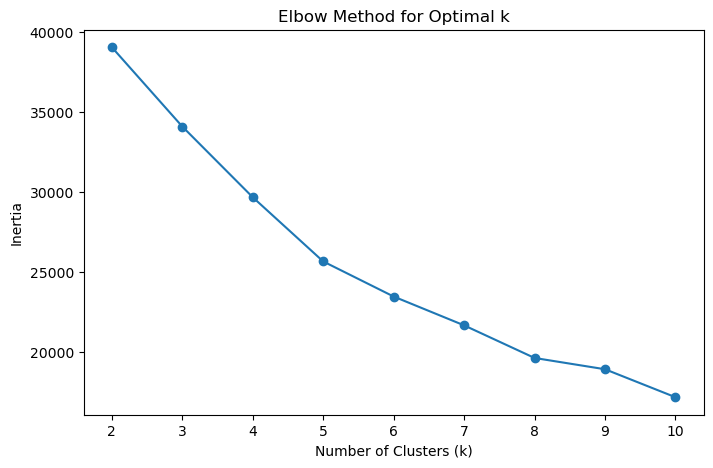

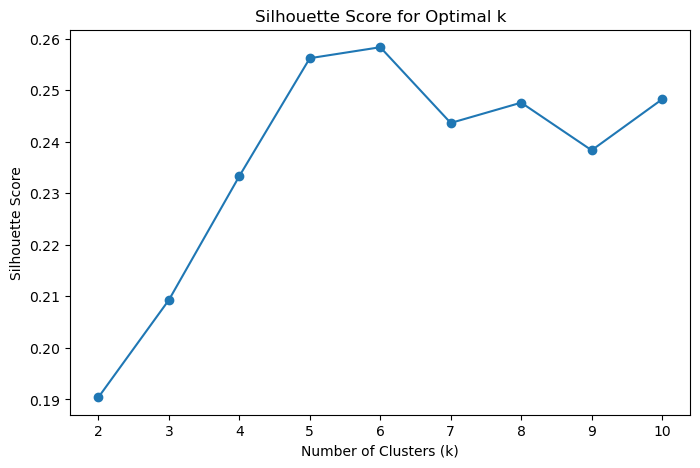

Cluster Summary:

         release_year  duration  genre_count  cast_count  country_count  \
cluster                                                                   
0             2016.56      3.21         2.68        8.82           1.00   
1             1986.35    108.02         2.31        8.65           1.17   
2             2016.48     52.25         1.27        3.34           1.01   
3             2014.69    108.36         2.51        8.58           1.34   

         description_length  
cluster                      
0                    142.35  
1                    150.21  
2                    143.21  
3                    142.46  

Interpretable Cluster Labels:

Cluster 0 - Mid-Age, Short, Structurally Rich
Cluster 1 - Older, Long, Structurally Rich, Global
Cluster 2 - Mid-Age, Short, Simple, Global
Cluster 3 - Mid-Age, Long, Structurally Rich, Global


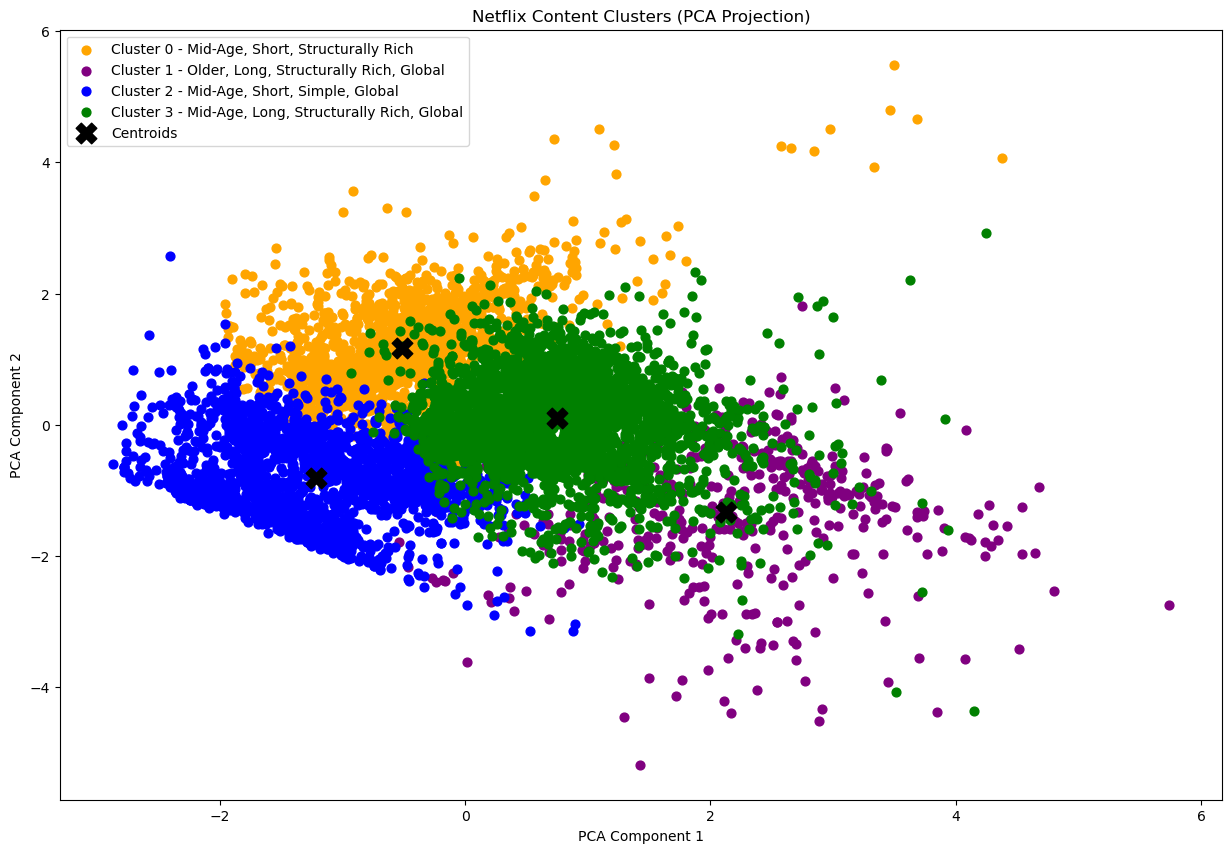


Cluster Counts:

cluster_name
Cluster 3 - Mid-Age, Long, Structurally Rich, Global    3415
Cluster 2 - Mid-Age, Short, Simple, Global              2161
Cluster 0 - Mid-Age, Short, Structurally Rich           1751
Cluster 1 - Older, Long, Structurally Rich, Global       460
Name: count, dtype: int64

Cluster Profile with Labels:

         release_year  duration  genre_count  cast_count  country_count  \
cluster                                                                   
0             2016.56      3.21         2.68        8.82           1.00   
1             1986.35    108.02         2.31        8.65           1.17   
2             2016.48     52.25         1.27        3.34           1.01   
3             2014.69    108.36         2.51        8.58           1.34   

         description_length                                      cluster_label  
cluster                                                                         
0                    142.35      Cluster 0 - Mid-Age, S

In [73]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# -----------------------------------
# 1. Select numeric features
# -----------------------------------
feature_cols = [
    "release_year",
    "duration",
    "genre_count",
    "cast_count",
    "country_count",
    "description_length"
]

X = df_clean[feature_cols].copy()

# -----------------------------------
# 2. Scale features
# -----------------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# -----------------------------------
# 3. Elbow Method
# -----------------------------------
inertias = []
k_values = range(2, 11)

for k in k_values:
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_values, inertias, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal k")
plt.show()

# -----------------------------------
# 4. Silhouette Score
# -----------------------------------
silhouette_scores = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
    cluster_labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, cluster_labels)
    silhouette_scores.append(score)

plt.figure(figsize=(8, 5))
plt.plot(k_values, silhouette_scores, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score for Optimal k")
plt.show()

# -----------------------------------
# 5. Final choice of k
# -----------------------------------
# Based on your earlier elbow + silhouette analysis
final_k = 4

# -----------------------------------
# 6. Train final KMeans model
# -----------------------------------
kmeans = KMeans(n_clusters=final_k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

# Add cluster ids
df_clean["cluster"] = clusters

# -----------------------------------
# 7. Cluster summary
# -----------------------------------
cluster_summary = df_clean.groupby("cluster")[feature_cols].mean().round(2)

print("Cluster Summary:\n")
print(cluster_summary)

# -----------------------------------
# 8. Build interpretable labels
# -----------------------------------
overall_medians = df_clean[feature_cols].median()

def make_cluster_label(row, medians):
    parts = []

    # Release year label
    if row["release_year"] >= medians["release_year"]:
        parts.append("Recent")
    elif row["release_year"] < medians["release_year"] - 10:
        parts.append("Older")
    else:
        parts.append("Mid-Age")

    # Duration label
    if row["duration"] >= medians["duration"]:
        parts.append("Long")
    else:
        parts.append("Short")

    # Richness label
    richness_score = 0
    if row["genre_count"] >= medians["genre_count"]:
        richness_score += 1
    if row["cast_count"] >= medians["cast_count"]:
        richness_score += 1
    if row["description_length"] >= medians["description_length"]:
        richness_score += 1

    if richness_score >= 2:
        parts.append("Structurally Rich")
    else:
        parts.append("Simple")

    # Country spread label
    if row["country_count"] > medians["country_count"]:
        parts.append("Global")

    return ", ".join(parts)

cluster_name_map = {
    cluster_id: f"Cluster {cluster_id} - {make_cluster_label(cluster_summary.loc[cluster_id], overall_medians)}"
    for cluster_id in cluster_summary.index
}

print("\nInterpretable Cluster Labels:\n")
for cluster_id, label in cluster_name_map.items():
    print(label)

df_clean["cluster_name"] = df_clean["cluster"].map(cluster_name_map)

# -----------------------------------
# 9. PCA for 2D visualization only
# -----------------------------------
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Transform centroids into PCA space
centers_pca = pca.transform(kmeans.cluster_centers_)

# -----------------------------------
# 10. Plot clusters
# -----------------------------------
plt.figure(figsize=(15, 10))
colors = ["orange", "purple", "blue", "green", "red", "brown"]

for i, cluster_id in enumerate(cluster_summary.index):
    plt.scatter(
        X_pca[clusters == cluster_id, 0],
        X_pca[clusters == cluster_id, 1],
        s=40,
        color=colors[i % len(colors)],
        label=cluster_name_map[cluster_id]
    )

# Plot centroids
plt.scatter(
    centers_pca[:, 0],
    centers_pca[:, 1],
    s=220,
    c="black",
    marker="X",
    label="Centroids"
)

plt.title("Netflix Content Clusters (PCA Projection)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend()
plt.show()

# -----------------------------------
# 11. Cluster counts
# -----------------------------------
print("\nCluster Counts:\n")
print(df_clean["cluster_name"].value_counts())

# -----------------------------------
# 12. Cluster profile with labels
# -----------------------------------
cluster_profile = cluster_summary.copy()
cluster_profile["cluster_label"] = cluster_profile.index.map(cluster_name_map)

print("\nCluster Profile with Labels:\n")
print(cluster_profile)

In [74]:
pca_df = pd.DataFrame(
    pca.components_,
    columns=feature_cols,
    index=["PC1", "PC2"]
)

pca_df

,release_year,duration,genre_count,cast_count,country_count,description_length
PC1,-0.457741,0.543020,0.397026,0.470831,0.326197,0.099431
PC2,0.337583,-0.348746,0.612369,0.458132,-0.247492,-0.343921


### CONCLUSION] The data suggests that older content is often longer and more complex, while newer content tends to be relatively shorter and simpler.

### Q2] Can we classify whether a Netflix title is ‘Content-Rich’ or ‘Simple’ based on features like duration, cast size, genres, and description length?

Accuracy: 0.8042362002567394

Classification Report:

              precision    recall  f1-score   support

Content-Rich       0.80      0.99      0.89      1198
      Simple       0.91      0.17      0.29       360

    accuracy                           0.80      1558
   macro avg       0.85      0.58      0.59      1558
weighted avg       0.83      0.80      0.75      1558



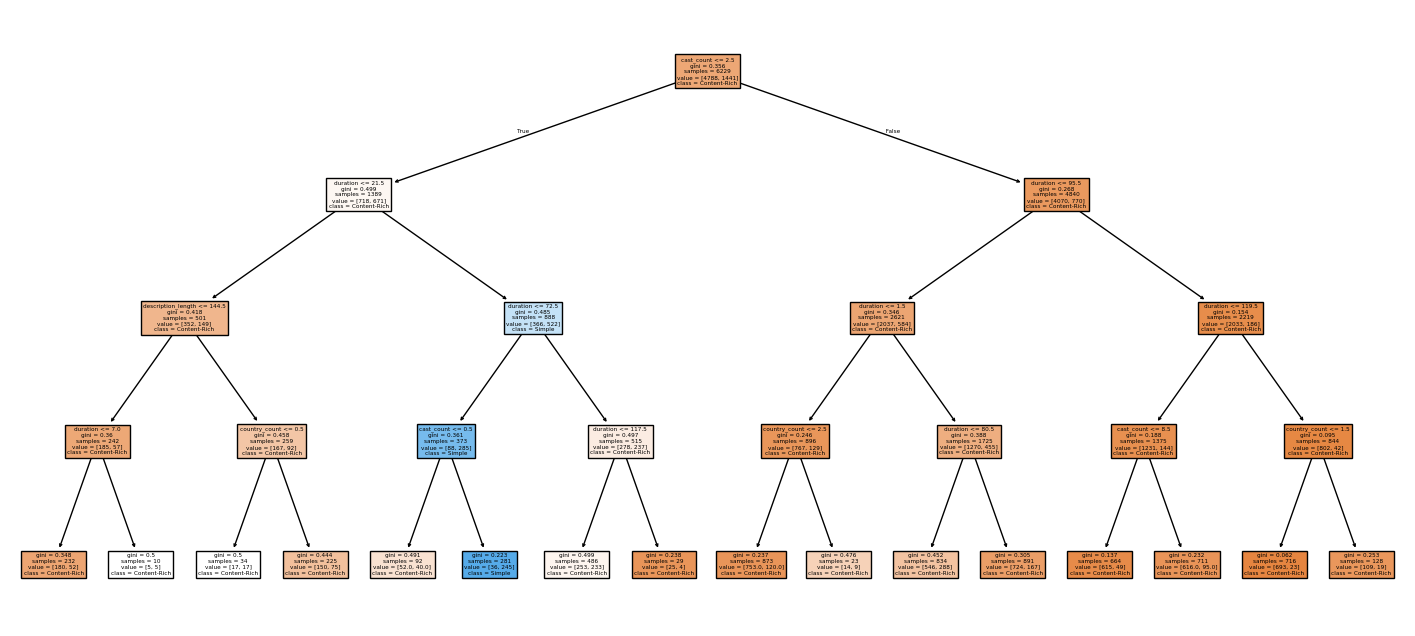

In [75]:
df_clean["content_type"] = df_clean["genre_count"].apply(
    lambda x: "Content-Rich" if x >= df_clean["genre_count"].median() else "Simple"
)

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report

X = df_clean[[
    "duration",
    "cast_count",
    "country_count",
    "description_length"
]].copy()

y = df_clean["content_type"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = DecisionTreeClassifier(max_depth=4, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

plt.figure(figsize=(18, 8))
plot_tree(
    model,
    feature_names=X.columns,
    class_names=model.classes_,
    filled=True
)
plt.show()

### Q3] Netflix claims that the average duration of content is 100 minutes. Is it true?

In [76]:
from statsmodels.stats.weightstats import ztest

sample = df_clean[df_clean['release_year'] >= 2020]['duration'].dropna()

z_stat, p_value = ztest(sample, value=100)

# Left-tailed test: H1 = average duration < 100
if z_stat < 0:
    p_value = p_value / 2
else:
    p_value = 1 - (p_value / 2)

print("Z-Statistic:", z_stat)
print("P-Value:", p_value)

alpha = 0.05
if p_value < alpha:
    print("\nReject H0")
    print("Modern content is significantly shorter than 100 minutes.")
else:
    print("\nFail to Reject H0")
    print("There is not enough evidence that modern content is shorter than 100 minutes.")

Z-Statistic: -34.96744134136605
P-Value: 3.5171670321817373e-268

Reject H0
Modern content is significantly shorter than 100 minutes.


### Q4] Is there a statistically significant difference in the average duration of Netflix Movies vs TV Shows?

In [77]:
from scipy.stats import ttest_ind

movies = df_clean[df_clean["type"] == "Movie"]['duration'].dropna()
tv_shows = df_clean[df_clean["type"] == "TV Show"]['duration'].dropna()

t_stat, p_value = ttest_ind(movies, tv_shows, equal_var=False)

print("T-Statistic:", t_stat)
print("P-Value:", p_value)

alpha = 0.05

if p_value < alpha:
    print("\nReject H0")
    print("There is a statistically significant difference in average duration.")
else:
    print("\nFail to Reject H0")
    print("No significant difference in average duration.")

T-Statistic: 249.79900942857398
P-Value: 0.0

Reject H0
There is a statistically significant difference in average duration.


### Q5] Is there a statistically significant difference in the average duration of Netflix content across different genres?

In [78]:
from scipy.stats import f_oneway

def extract_main_genre(x):
    if pd.isna(x):
        return 'Other'
    x = str(x).lower()
    if 'drama' in x:
        return 'Drama'
    elif 'comedy' in x:
        return 'Comedy'
    elif 'documentary' in x:
        return 'Documentary'
    else:
        return 'Other'

df_clean['main_genre'] = df_clean['genres'].apply(extract_main_genre)

anova_df = df_clean[df_clean['main_genre'].isin(['Drama', 'Comedy', 'Documentary'])].copy()

drama = anova_df[anova_df['main_genre'] == 'Drama']['duration'].dropna()
comedy = anova_df[anova_df['main_genre'] == 'Comedy']['duration'].dropna()
documentary = anova_df[anova_df['main_genre'] == 'Documentary']['duration'].dropna()

f_stat, p_value = f_oneway(drama, comedy, documentary)

print("F-Statistic:", f_stat)
print("P-Value:", p_value)

alpha = 0.05

if p_value < alpha:
    print("\nReject Null Hypothesis (H0)")
    print("There is a significant difference in average duration across genres.")
else:
    print("\nFail to Reject Null Hypothesis (H0)")
    print("No significant difference in average duration across genres.")

F-Statistic: nan
P-Value: nan

Fail to Reject Null Hypothesis (H0)
No significant difference in average duration across genres.


### Q6] Is there a statistically significant association between content type (Movie vs TV Show) and content rating category (for example Kids, Teens, Adults) on Netflix?

In [79]:
from scipy.stats import chi2_contingency

def rating_category(rating):
    kids = ['G', 'TV-G', 'TV-Y', 'TV-Y7']
    teens = ['PG', 'TV-PG', 'PG-13', 'TV-14']
    adults = ['R', 'NC-17', 'TV-MA']

    if rating in kids:
        return 'Kids'
    elif rating in teens:
        return 'Teens'
    elif rating in adults:
        return 'Adults'
    else:
        return 'Other'

df_clean['rating_group'] = df_clean['rating'].apply(rating_category)

cont_table = pd.crosstab(df_clean['type'], df_clean['rating_group'])

print("Contingency Table:\n")
print(cont_table)

chi2_stat, p_value, dof, expected = chi2_contingency(cont_table)

print("\nChi-Square Statistic:", chi2_stat)
print("P-Value:", p_value)
print("Degrees of Freedom:", dof)

alpha = 0.05

if p_value < alpha:
    print("\nReject Null Hypothesis (H0)")
    print("There is a significant association between content type and rating category.")
else:
    print("\nFail to Reject Null Hypothesis (H0)")
    print("No significant association between content type and rating category.")

Contingency Table:

rating_group  Adults  Kids  Other  Teens
type                                    
Movie           2511   362     94   2410
TV Show         1020   422      8    960

Chi-Square Statistic: 234.07533384399608
P-Value: 1.8182290180291904e-50
Degrees of Freedom: 3

Reject Null Hypothesis (H0)
There is a significant association between content type and rating category.


### Q7] Netflix historically claims that the average cast size is 10 actors per title. Using recently added content (added_year >= 2020), test whether the average cast size is significantly lower than 10.

In [80]:
from statsmodels.stats.weightstats import ztest

recent_content = df_clean[df_clean["added_year"] > 2019]["cast_count"].dropna()

z_stat, p_value = ztest(recent_content, value=10)

# Left-tailed test: H1 = average cast count < 10
p_value = p_value / 2

print("Z-Statistic:", z_stat)
print("P-Value:", p_value)

alpha = 0.05

if p_value < alpha:
    print("\nReject H0")
    print("Average cast is significantly lower than 10.")
else:
    print("\nFail to Reject H0")
    print("Average cast is not significantly lower than 10.")

Z-Statistic: -19.766052015675466
P-Value: 2.918439740348507e-87

Reject H0
Average cast is significantly lower than 10.


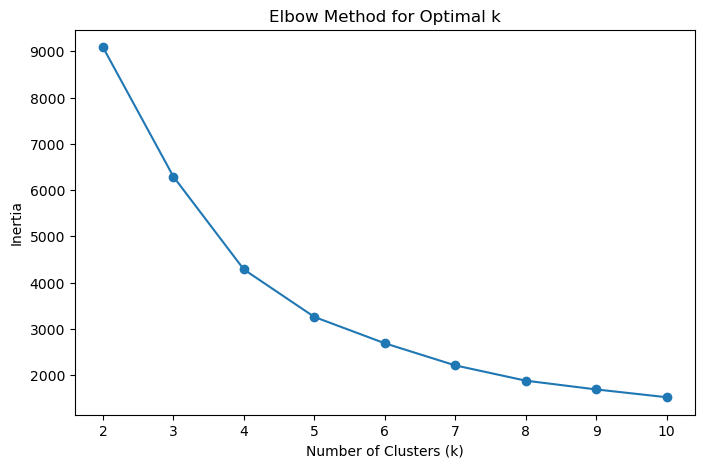

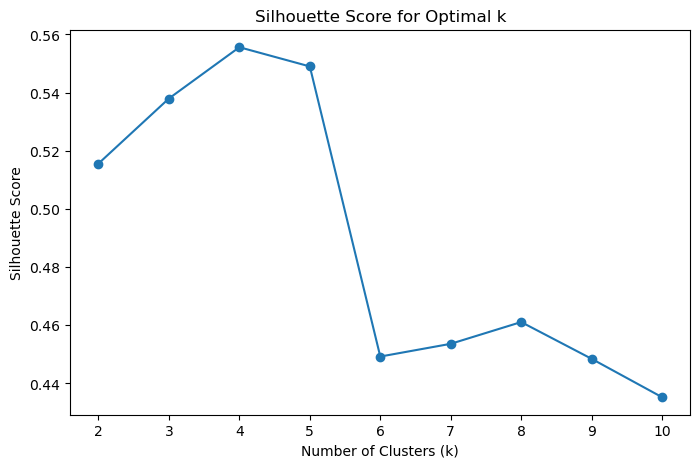

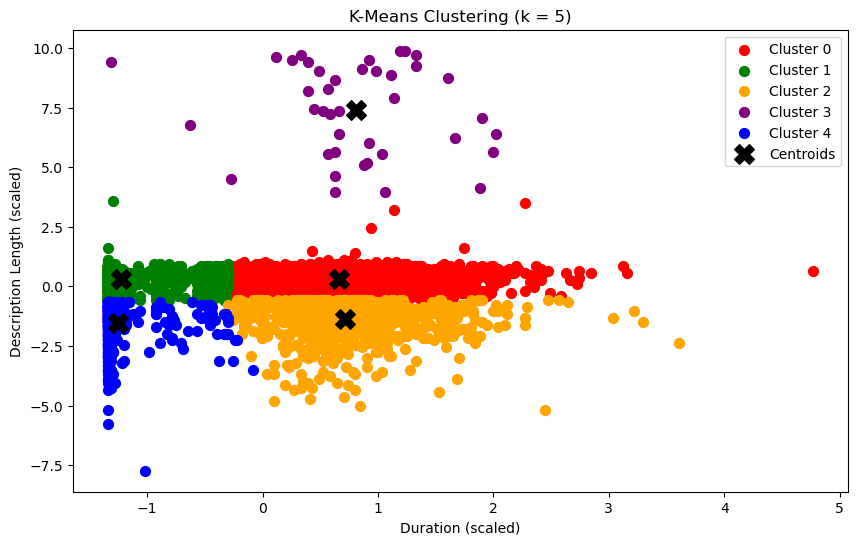

In [81]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# -------------------------------
# 1. Select features
# -------------------------------
feature_cols = ["duration", "description_length"]
X = df_clean[feature_cols].copy()

# -------------------------------
# 2. Scale the data
# -------------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# -------------------------------
# 3. Elbow Method
# -------------------------------
inertias = []
k_values = range(2, 11)

for k in k_values:
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_values, inertias, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal k")
plt.show()

# -------------------------------
# 4. Silhouette Score
# -------------------------------
silhouette_scores = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
    cluster_labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, cluster_labels)
    silhouette_scores.append(score)

plt.figure(figsize=(8, 5))
plt.plot(k_values, silhouette_scores, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score for Optimal k")
plt.show()

# -------------------------------
# 5. Choose final k using business sense
# -------------------------------
# Example:
# - If elbow bends near 3 or 4
# - and silhouette score is also strong around 3 or 4
# - then choose the one that is easier to explain to business
#
# Change this after observing both graphs
final_k = 5

# -------------------------------
# 6. Final KMeans model
# -------------------------------
kmeans = KMeans(n_clusters=final_k, n_init=10, random_state=42)
y_kmeans = kmeans.fit_predict(X_scaled)
centers = kmeans.cluster_centers_

# -------------------------------
# 7. Plot final clusters
# -------------------------------
plt.figure(figsize=(10, 6))

colors = ['red', 'green', 'orange', 'purple', 'blue', 'brown', 'pink', 'gray']
labels = [f'Cluster {i}' for i in range(final_k)]

for i in range(final_k):
    plt.scatter(
        X_scaled[y_kmeans == i, 0],
        X_scaled[y_kmeans == i, 1],
        s=50,
        color=colors[i],
        label=labels[i]
    )

# Plot centroids
plt.scatter(
    centers[:, 0],
    centers[:, 1],
    c='black',
    s=200,
    marker='X',
    label='Centroids'
)

plt.xlabel("Duration (scaled)")
plt.ylabel("Description Length (scaled)")
plt.title(f"K-Means Clustering (k = {final_k})")
plt.legend()
plt.show()